# Support Integrity Auditor (SIA)
# Day 1 EDA Notebook

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv('/content/drive/MyDrive/mars_2026/customer_support_tickets.csv')
print('Shape:', df.shape)
df.head()


Shape: (20000, 12)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_ID,20000,20000,TKT-119983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,20000,17900,William Smith,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,20000,19489,vjohnson@example.org,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Subject,20000,13943,Refund status - Ball,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Description,20000,20000,"Hi Support, I lost my phone and cannot pass th...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_Category,20000,5,Technical,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority_Level,20000,4,Low,7716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Channel,20000,3,Chat,6693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Submission_Date,20000,731,2025-05-11,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resolution_Time_Hours,20000.0,NaN,NaN,NaN,39.2303,35.221884,1.0,11.0,27.0,58.0,120.0


In [8]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round(df.isnull().mean()*100,2)
})
missing.sort_values(by='Percentage', ascending=False)


,Missing Values,Percentage
Ticket_ID,0,0.0
Customer_Name,0,0.0
Customer_Email,0,0.0
Ticket_Subject,0,0.0
Ticket_Description,0,0.0
Issue_Category,0,0.0
Priority_Level,0,0.0
Ticket_Channel,0,0.0
Submission_Date,0,0.0
Resolution_Time_Hours,0,0.0


In [9]:
print('Duplicate Rows:', df.duplicated().sum())
print('Unique Ticket IDs:', df['Ticket_ID'].nunique())


Duplicate Rows: 0
Unique Ticket IDs: 20000


## Priority Analysis

In [10]:
df['Priority_Level'].value_counts()

,count
Priority_Level,
Low,7716
Medium,7570
High,3416
Critical,1298


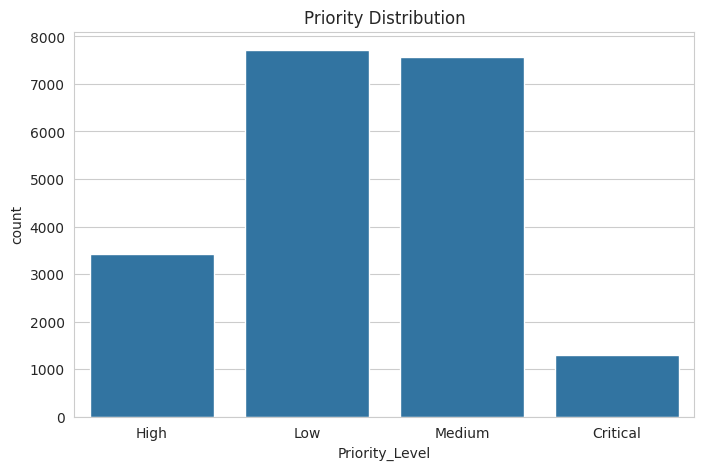

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Priority_Level', data=df)
plt.title('Priority Distribution')
plt.show()


## Issue Category Analysis

In [12]:
df['Issue_Category'].value_counts()

,count
Issue_Category,
Technical,5918
Billing,5036
Account,4081
General Inquiry,3925
Fraud,1040


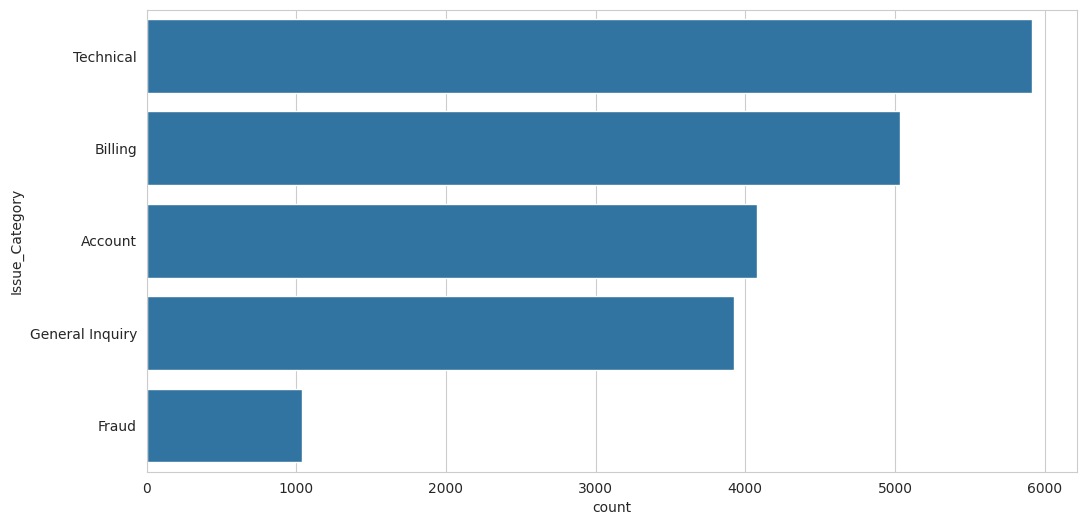

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(y='Issue_Category', data=df,
order=df['Issue_Category'].value_counts().index)
plt.show()


## Ticket Channel Analysis

In [14]:
df['Ticket_Channel'].value_counts()

,count
Ticket_Channel,
Chat,6693
Email,6656
Web Form,6651


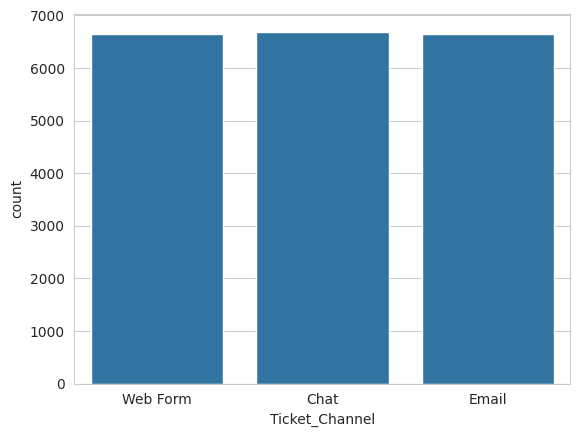

In [15]:
sns.countplot(x='Ticket_Channel', data=df)
plt.show()


## Resolution Time Analysis

In [16]:
df['Resolution_Time_Hours'].describe()

,Resolution_Time_Hours
count,20000.000000
mean,39.230300
std,35.221884
min,1.000000
25%,11.000000
50%,27.000000
75%,58.000000
max,120.000000


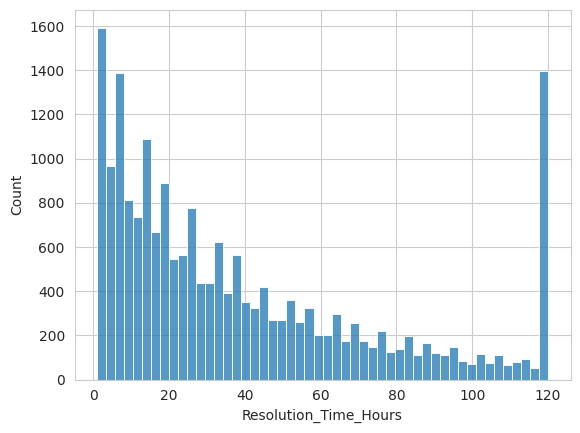

In [17]:
sns.histplot(df['Resolution_Time_Hours'], bins=50)
plt.show()


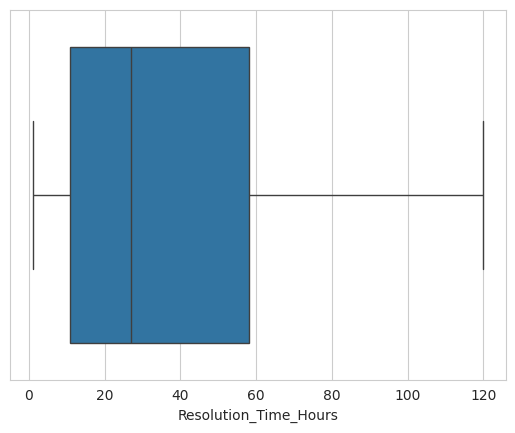

In [18]:
sns.boxplot(x=df['Resolution_Time_Hours'])
plt.show()


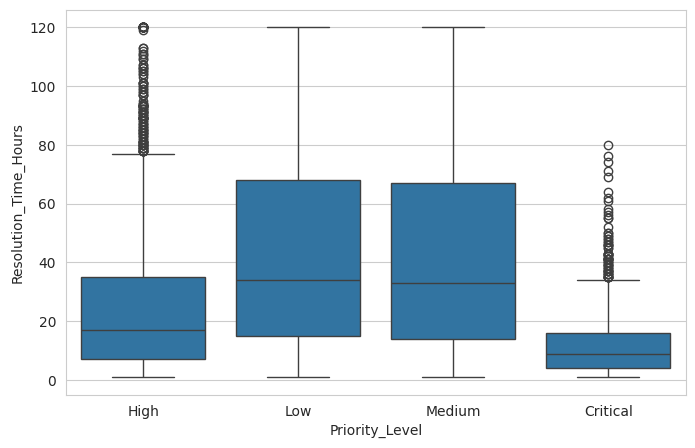

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Priority_Level', y='Resolution_Time_Hours', data=df)
plt.show()


## Satisfaction Score Analysis

In [20]:
df['Satisfaction_Score'].describe()

,Satisfaction_Score
count,20000.000000
mean,3.723700
std,1.286989
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


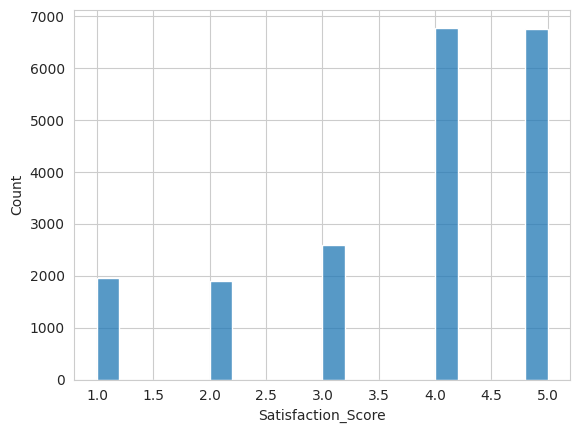

In [21]:
sns.histplot(df['Satisfaction_Score'], bins=20)
plt.show()


## Channel vs Priority

In [22]:
cross = pd.crosstab(df['Ticket_Channel'], df['Priority_Level'])
cross


Priority_Level,Critical,High,Low,Medium
Ticket_Channel,,,,
Chat,433,1133,2605,2522
Email,430,1117,2545,2564
Web Form,435,1166,2566,2484


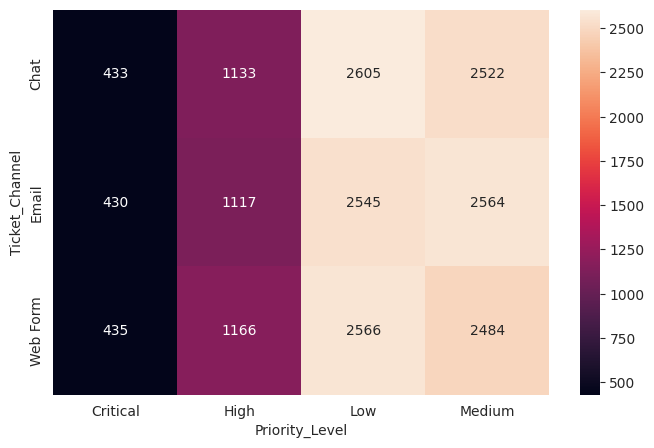

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(cross, annot=True, fmt='d')
plt.show()


## Category vs Priority

In [24]:
cross2 = pd.crosstab(df['Issue_Category'], df['Priority_Level'])
cross2


Priority_Level,Critical,High,Low,Medium
Issue_Category,,,,
Account,0,405,2054,1622
Billing,0,550,2524,1962
Fraud,716,324,0,0
General Inquiry,0,389,1968,1568
Technical,582,1748,1170,2418


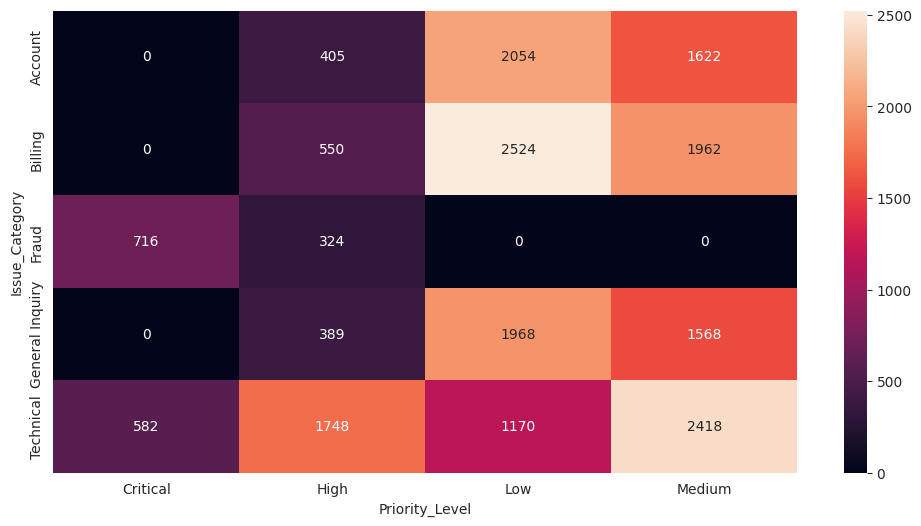

In [25]:
plt.figure(figsize=(12,6))
sns.heatmap(cross2, annot=True, fmt='d')
plt.show()


## Text Analysis

In [26]:
df['combined_text'] = df['Ticket_Subject'].astype(str)+' '+df['Ticket_Description'].astype(str)
df['ticket_length'] = df['combined_text'].str.split().apply(len)
df[['combined_text','ticket_length']].head()


,combined_text,ticket_length
0,"Hours of operation - Individual Hi Support, Wh...",18
1,"Data not syncing - Card Hi Support, The applic...",22
2,"2FA issues - Question Hi Support, How do I upg...",20
3,"Login failed - Let Hi Support, The dashboard i...",21
4,"Refund status - Attention Hi Support, I have b...",22


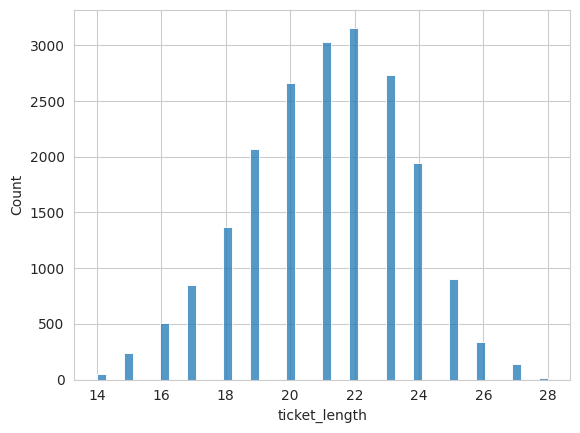

In [27]:
sns.histplot(df['ticket_length'], bins=50)
plt.show()


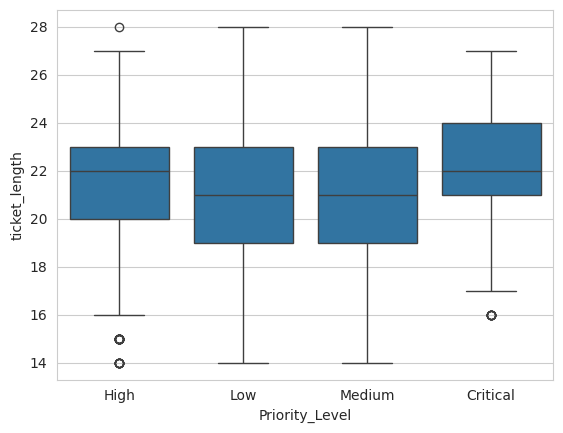

In [28]:
sns.boxplot(x='Priority_Level', y='ticket_length', data=df)
plt.show()


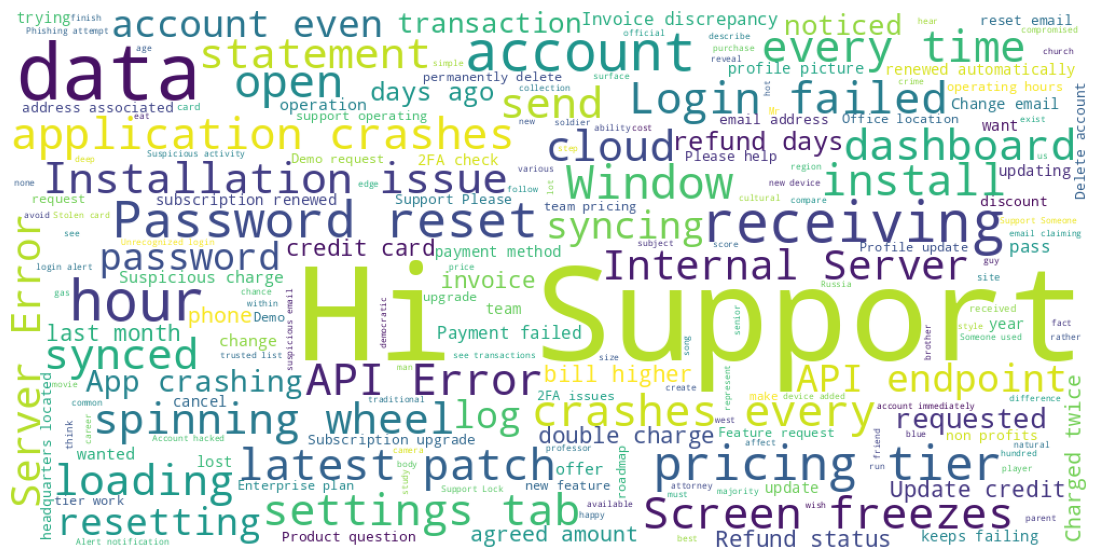

In [29]:
text = ' '.join(df['combined_text'].astype(str))
wc = WordCloud(width=1000,height=500,background_color='white').generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis('off')
plt.show()


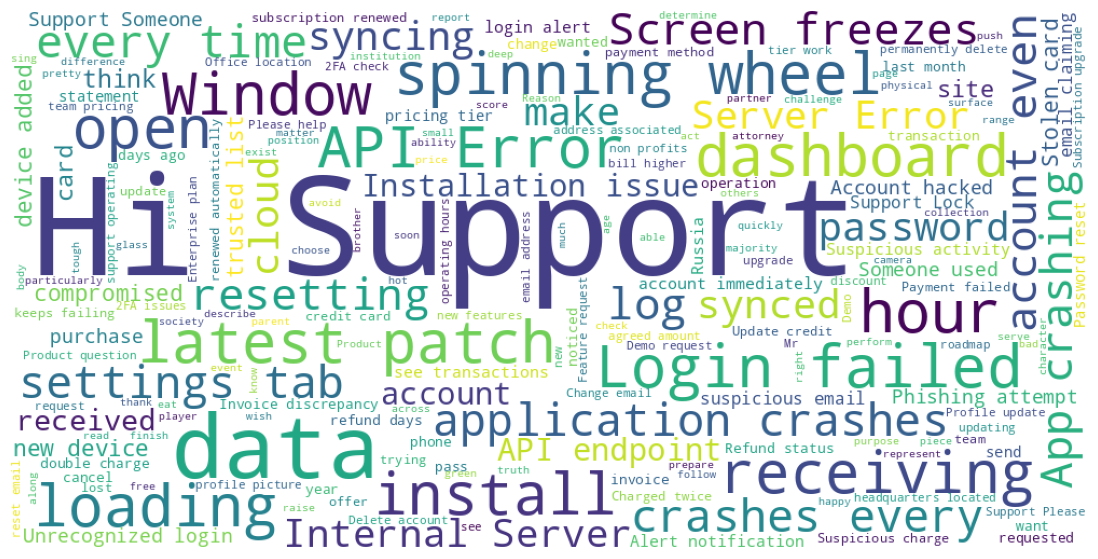

In [30]:
high_text = ' '.join(df[df['Priority_Level'].isin(['High','Critical'])]['combined_text'].astype(str))
wc = WordCloud(width=1000,height=500,background_color='white').generate(high_text)
plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis('off')
plt.show()


## Correlation Analysis

In [31]:
priority_map={'Low':0,'Medium':1,'High':2,'Critical':3}
df['priority_num']=df['Priority_Level'].map(priority_map)

corr_df=df[['priority_num','Resolution_Time_Hours','Satisfaction_Score','ticket_length']]
corr_df.corr()


,priority_num,Resolution_Time_Hours,Satisfaction_Score,ticket_length
priority_num,1.000000,-0.262923,-0.005262,0.152906
Resolution_Time_Hours,-0.262923,1.000000,-0.002962,-0.042724
Satisfaction_Score,-0.005262,-0.002962,1.000000,-0.078055
ticket_length,0.152906,-0.042724,-0.078055,1.000000


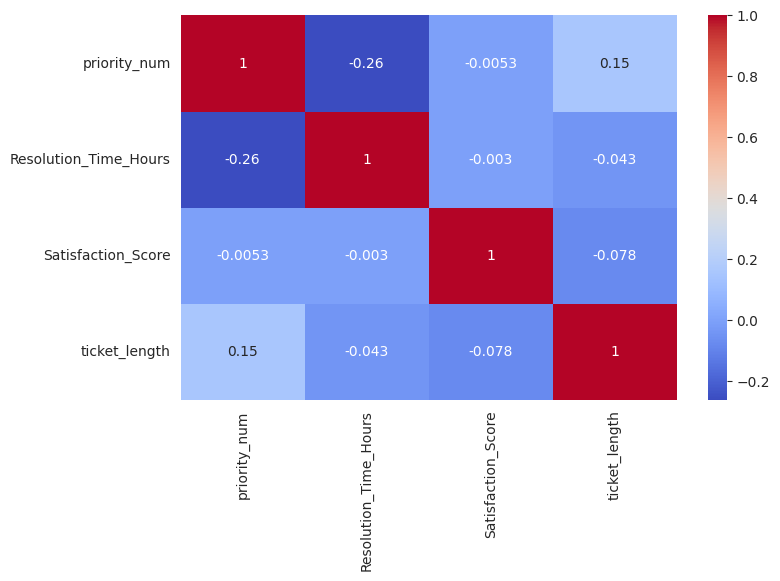

In [32]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.show()


## Feature Engineering


In [33]:
df['combined_text'] = (
    df['Ticket_Subject'].fillna('') +
    ' ' +
    df['Ticket_Description'].fillna('')
)

In [34]:
df[['Ticket_Subject',
    'Ticket_Description',
    'combined_text']].head()

,Ticket_Subject,Ticket_Description,combined_text
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...","Hours of operation - Individual Hi Support, Wh..."
1,Data not syncing - Card,"Hi Support, The application crashes every time...","Data not syncing - Card Hi Support, The applic..."
2,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...","2FA issues - Question Hi Support, How do I upg..."
3,Login failed - Let,"Hi Support, The dashboard is not loading any d...","Login failed - Let Hi Support, The dashboard i..."
4,Refund status - Attention,"Hi Support, I have been trying to update my pa...","Refund status - Attention Hi Support, I have b..."


In [35]:
!pip install nltk

In [36]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [37]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [38]:
df['clean_text'] = (
    df['combined_text']
    .apply(clean_text)
)

In [39]:
df[
[
'combined_text',
'clean_text'
]
].head()

,combined_text,clean_text
0,"Hours of operation - Individual Hi Support, Wh...",hour operation individual hi support headquart...
1,"Data not syncing - Card Hi Support, The applic...",data syncing card hi support application crash...
2,"2FA issues - Question Hi Support, How do I upg...",fa issue question hi support upgrade enterpris...
3,"Login failed - Let Hi Support, The dashboard i...",login failed let hi support dashboard loading ...
4,"Refund status - Attention Hi Support, I have b...",refund status attention hi support trying upda...


In [40]:
df['char_count'] = (
    df['combined_text']
    .apply(len)
)

In [41]:
df['word_count'] = (
    df['combined_text']
    .str.split()
    .apply(len)
)

In [42]:
df[
[
'char_count',
'word_count'
]
].describe()

,char_count,word_count
count,20000.000000,20000.00000
mean,123.881150,21.10555
std,15.104673,2.45628
min,81.000000,14.00000
25%,113.000000,19.00000
50%,124.000000,21.00000
75%,134.000000,23.00000
max,179.000000,28.00000


In [43]:
df['Resolution_Time_Hours'].dtype
df['Resolution_Time_Hours'] = (
    pd.to_numeric(
        df['Resolution_Time_Hours'],
        errors='coerce'
    )
)

In [44]:
def resolution_bucket(hours):

    if hours <= 12:
        return 'Low'

    elif hours <= 24:
        return 'Medium'

    elif hours <= 48:
        return 'High'

    else:
        return 'Critical'

In [45]:
df['resolution_severity'] = (
    df['Resolution_Time_Hours']
    .apply(resolution_bucket)
)

In [46]:
df['resolution_severity'].value_counts()

,count
resolution_severity,
Critical,6154
Low,5499
High,4593
Medium,3754


In [47]:
def satisfaction_bucket(score):

    if score <= 2:
        return 'Poor'

    elif score <= 3:
        return 'Average'

    else:
        return 'Good'

In [48]:
df['satisfaction_bucket'] = (
    df['Satisfaction_Score']
    .apply(satisfaction_bucket)
)

In [49]:
critical_keywords = [

'outage',
'server down',
'data loss',
'security breach',
'payment failed',
'fraud',
'hacked',
'cannot access',
'account locked',
'system failure'
]

In [50]:
high_keywords = [

'crash',
'error',
'unable',
'failed',
'urgent',
'broken',
'issue',
'bug'
]

In [51]:
def keyword_score(text):

    text = text.lower()

    score = 0

    for word in critical_keywords:

        if word in text:
            score += 3

    for word in high_keywords:

        if word in text:
            score += 1

    return score

In [52]:
df['keyword_score'] = (
    df['combined_text']
    .apply(keyword_score)
)
df['keyword_score'].describe()

,keyword_score
count,20000.000000
mean,0.510900
std,0.951854
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,5.000000


In [53]:
severity_features = df[
[
'Ticket_ID',
'Priority_Level',
'Resolution_Time_Hours',
'Satisfaction_Score',
'keyword_score',
'char_count',
'word_count'
]
]

In [54]:
severity_features.head()

,Ticket_ID,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,keyword_score,char_count,word_count
0,TKT-100000,High,43,5,0,112,18
1,TKT-100001,High,41,5,1,122,22
2,TKT-100002,High,7,5,1,108,20
3,TKT-100003,Low,41,5,1,119,21
4,TKT-100004,Medium,40,5,0,124,22


Severity


In [55]:
severity_map = {

    'Low':0,
    'Medium':1,
    'High':2,
    'Critical':3

}

In [56]:
df['resolution_signal'] = (
    df['resolution_severity']
    .map(severity_map)
)

In [57]:
df[
[
'Resolution_Time_Hours',
'resolution_signal'
]
].head()

,Resolution_Time_Hours,resolution_signal
0,43,2
1,41,2
2,7,0
3,41,2
4,40,2


In [58]:
keyword_score

<function __main__.keyword_score(text)>

In [59]:
def keyword_severity(score):

    if score == 0:
        return 0

    elif score <= 2:
        return 1

    elif score <= 5:
        return 2

    else:
        return 3

In [60]:
df['keyword_signal'] = (
    df['keyword_score']
    .apply(keyword_severity)
)

In [61]:
df['keyword_signal'].value_counts()

,count
keyword_signal,
0,13657
1,5335
2,1008


In [62]:
def satisfaction_signal(score):

    if score >= 4:
        return 0

    elif score >= 3:
        return 1

    elif score >= 2:
        return 2

    else:
        return 3

In [63]:
df['satisfaction_signal'] = (
    df['Satisfaction_Score']
    .apply(satisfaction_signal)
)

In [64]:
!pip install sentence-transformers

In [65]:
from sentence_transformers import SentenceTransformer

In [66]:
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [67]:
embeddings = model.encode(
    df['clean_text'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

In [68]:
print(embeddings.shape)

(20000, 384)


In [69]:
from sklearn.cluster import KMeans

In [70]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [71]:
clusters = kmeans.fit_predict(
    embeddings
)

In [72]:
df['cluster'] = clusters

In [73]:
df['cluster'].value_counts()

,count
cluster,
2,5559
1,5194
3,4949
0,4298


In [74]:
for c in range(4):

    print("="*50)

    print("Cluster",c)

    display(
        df[
            df['cluster']==c
        ][
            'Ticket_Description'
        ].head(5)
    )

Cluster 0


,Ticket_Description
0,"Hi Support, Where is your headquarters located..."
2,"Hi Support, How do I upgrade to the Enterprise..."
5,"Hi Support, Where is your headquarters located..."
9,"Hi Support, Is there a roadmap for new feature..."
10,"Hi Support, Where is your headquarters located..."


Cluster 1


,Ticket_Description
4,"Hi Support, I have been trying to update my pa..."
7,"Hi Support, My subscription renewed automatica..."
14,"Hi Support, I requested a refund 5 days ago, w..."
18,"Hi Support, Can you send me the invoice for tr..."
19,"Hi Support, Why is my bill higher than the agr..."


Cluster 2


,Ticket_Description
6,"Hi Support, How do I upgrade to the Enterprise..."
8,"Hi Support, I cannot log into my account even ..."
11,"Hi Support, I want to permanently delete my ac..."
17,"Hi Support, My profile picture is not updating..."
20,"Hi Support, I want to permanently delete my ac..."


Cluster 3


,Ticket_Description
1,"Hi Support, The application crashes every time..."
3,"Hi Support, The dashboard is not loading any d..."
12,"Hi Support, My data hasn't synced to the cloud..."
27,"Hi Support, How do I install the latest patch ..."
28,"Hi Support, How do I install the latest patch ..."


In [75]:
cluster_severity = {

0:1,
1:2,
2:3,
3:0

}

In [76]:
df['cluster_signal'] = (
    df['cluster']
    .map(cluster_severity)
)

In [77]:
agreement = (
    df['resolution_signal']
    ==
    df['keyword_signal']
).mean()

print(agreement)

0.2467


In [78]:
(
df['resolution_signal']
==
df['cluster_signal']
).mean()

np.float64(0.25845)

In [79]:
df['severity_score'] = (

0.35*df['resolution_signal']

+

0.25*df['keyword_signal']

+

0.15*df['satisfaction_signal']

+

0.25*df['cluster_signal']

)

In [80]:
df['severity_score'].describe()

,severity_score
count,20000.000000
mean,1.125627
std,0.535488
min,0.000000
25%,0.750000
50%,1.100000
75%,1.500000
max,2.750000


In [81]:
def severity_bucket(score):

    if score < 0.75:
        return 'Low'

    elif score < 1.5:
        return 'Medium'

    elif score < 2.25:
        return 'High'

    else:
        return 'Critical'

In [82]:
df['inferred_severity'] = (
    df['severity_score']
    .apply(severity_bucket)
)

In [83]:
df['inferred_severity'].value_counts()

,count
inferred_severity,
Medium,10105
High,4870
Low,4765
Critical,260


In [84]:
df['priority_num'] = (
    df['Priority_Level']
    .map(severity_map)
)

df['inferred_num'] = (
    df['inferred_severity']
    .map(severity_map)
)

In [85]:
df['Mismatch_Label'] = (

abs(
df['priority_num']
-
df['inferred_num']
)

>=2

).astype(int)

In [86]:
df['Mismatch_Label'].value_counts()

,count
Mismatch_Label,
0,15056
1,4944


In [87]:
df['Hidden_Crisis'] = (

df['inferred_num']
>
df['priority_num']

)

In [88]:
df['False_Alarm'] = (

df['inferred_num']
<
df['priority_num']

)

In [89]:
df.to_csv(
    'pseudo_labeled_dataset.csv',
    index=False
)

In [90]:
df['severity_score'] = (
    0.5*df['resolution_signal']
    + 0.3*df['keyword_signal']
    + 0.2*df['satisfaction_signal']
)

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [92]:
X = df['clean_text']
y = df['Mismatch_Label']

In [93]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1,2))

X = tfidf.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.77      0.97      0.86      3037
           1       0.52      0.09      0.16       963

    accuracy                           0.76      4000
   macro avg       0.64      0.53      0.51      4000
weighted avg       0.71      0.76      0.69      4000



In [94]:
import joblib

joblib.dump(rf,'sia_model.pkl')
joblib.dump(tfidf,'tfidf.pkl')

['tfidf.pkl']

In [95]:
def generate_dossier(row):

    return {
        "ticket_id": row["Ticket_ID"],
        "assigned_priority": row["Priority_Level"],
        "inferred_severity": row["inferred_severity"],
        "mismatch_type":
            "Hidden Crisis"
            if row["inferred_num"] >
               row["priority_num"]
            else "False Alarm"
    }

In [96]:
!pip install streamlit

In [97]:
import streamlit as st
import pandas as pd

st.title("Support Integrity Auditor")

uploaded = st.file_uploader(
    "Upload CSV"
)

if uploaded:

    df = pd.read_csv(uploaded)

    st.dataframe(df.head())

2026-06-15 17:33:50.348 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:33:50.544 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-15 17:33:50.545 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:33:50.546 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:33:50.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:33:50.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:33:50.549 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:33:50.550 Thread 'MainThread': mi

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [99]:
X = df['clean_text']
y = df['Mismatch_Label']

In [100]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X)

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [103]:
pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.746
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      3011
           1       0.47      0.19      0.26       989

    accuracy                           0.75      4000
   macro avg       0.62      0.56      0.56      4000
weighted avg       0.70      0.75      0.70      4000



In [104]:
import joblib

joblib.dump(rf, "sia_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [105]:
def generate_dossier(row):

    if row['inferred_num'] > row['priority_num']:
        mismatch_type = "Hidden Crisis"
    else:
        mismatch_type = "False Alarm"

    return {
        "ticket_id": row["Ticket_ID"],
        "assigned_priority": row["Priority_Level"],
        "inferred_severity": row["inferred_severity"],
        "mismatch_type": mismatch_type,
        "severity_delta": abs(
            row["inferred_num"] -
            row["priority_num"]
        )
    }

In [106]:
dossiers = []

for _, row in df[df['Mismatch_Label']==1].head(100).iterrows():
    dossiers.append(generate_dossier(row))

pd.DataFrame(dossiers).head()

,ticket_id,assigned_priority,inferred_severity,mismatch_type,severity_delta
0,TKT-100002,High,Low,False Alarm,2
1,TKT-100011,Low,High,Hidden Crisis,2
2,TKT-100012,Critical,Low,False Alarm,3
3,TKT-100024,Low,High,Hidden Crisis,2
4,TKT-100029,Low,High,Hidden Crisis,2


In [107]:
pd.DataFrame(dossiers).to_csv(
    "evidence_dossiers.csv",
    index=False
)

In [108]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("sia_model.pkl")
tfidf = joblib.load("tfidf.pkl")

st.title("Support Integrity Auditor")

text = st.text_area("Enter Ticket")

if st.button("Predict"):

    x = tfidf.transform([text])

    pred = model.predict(x)[0]

    if pred == 1:
        st.error("Priority Mismatch Detected")
    else:
        st.success("Priority Consistent")

2026-06-15 17:38:08.822 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.824 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.827 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.830 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:08.831 Session state does not function when running a script without `streamlit run`
2026-06-15 17:38

In [109]:
import os

files_to_check = [
    "pseudo_labeled_dataset.csv",
    "sia_model.pkl",
    "tfidf.pkl"
]

for f in files_to_check:
    print(f, "✅" if os.path.exists(f) else "❌")

pseudo_labeled_dataset.csv ✅
sia_model.pkl ✅
tfidf.pkl ✅


In [110]:
def generate_dossier(row):

    mismatch_type = (
        "Hidden Crisis"
        if row["inferred_num"] > row["priority_num"]
        else "False Alarm"
    )

    return {
        "ticket_id": row["Ticket_ID"],
        "assigned_priority": row["Priority_Level"],
        "inferred_severity": row["inferred_severity"],
        "mismatch_type": mismatch_type,
        "severity_delta": abs(
            row["inferred_num"] - row["priority_num"]
        )
    }

dossiers = []

for _, row in df[df["Mismatch_Label"] == 1].iterrows():
    dossiers.append(generate_dossier(row))

dossier_df = pd.DataFrame(dossiers)

dossier_df.to_csv(
    "evidence_dossiers.csv",
    index=False
)

print(dossier_df.head())

    ticket_id assigned_priority inferred_severity  mismatch_type  \
0  TKT-100002              High               Low    False Alarm   
1  TKT-100011               Low              High  Hidden Crisis   
2  TKT-100012          Critical               Low    False Alarm   
3  TKT-100024               Low              High  Hidden Crisis   
4  TKT-100029               Low              High  Hidden Crisis   

   severity_delta  
0               2  
1               2  
2               3  
3               2  
4               2  


In [111]:
import streamlit as st
import joblib

model = joblib.load("sia_model.pkl")
tfidf = joblib.load("tfidf.pkl")

st.title("Support Integrity Auditor")

ticket = st.text_area("Enter Ticket Description")

if st.button("Analyze"):

    x = tfidf.transform([ticket])

    pred = model.predict(x)[0]

    if pred == 1:
        st.error("Priority Mismatch Detected")
    else:
        st.success("Priority Consistent")

2026-06-15 17:38:10.834 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.836 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.844 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 17:38:10.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [129]:
df["Mismatch_Label"].value_counts(normalize=True)

,proportion
Mismatch_Label,
0,0.7528
1,0.2472


In [136]:
from sklearn.preprocessing import LabelEncoder

channel_encoder = LabelEncoder()
category_encoder = LabelEncoder()

df['channel_enc'] = channel_encoder.fit_transform(
    df['Ticket_Channel']
)

df['category_enc'] = category_encoder.fit_transform(
    df['Issue_Category']
)

In [137]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2
)

X_text = tfidf.fit_transform(df['clean_text'])

In [138]:
metadata = df[
    [
        'Resolution_Time_Hours',
        'Satisfaction_Score',
        'channel_enc',
        'category_enc',
        'word_count'
    ]
]

In [139]:
from scipy.sparse import hstack

X = hstack([X_text, metadata.values])

y = df['Mismatch_Label']

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [141]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [142]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Macro F1:", f1_score(y_test, pred, average='macro'))

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

Accuracy: 0.7935
Macro F1: 0.7096022852120414
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      3011
           1       0.59      0.52      0.55       989

    accuracy                           0.79      4000
   macro avg       0.72      0.70      0.71      4000
weighted avg       0.79      0.79      0.79      4000

[[2662  349]
 [ 477  512]]


In [143]:
neg = sum(y_train == 0)
pos = sum(y_train == 1)

scale_pos_weight = neg / pos

print(scale_pos_weight)

3.04551201011378


In [144]:
xgb = XGBClassifier(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=-1,
              num_parallel_tree=None, ...)

In [145]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Macro F1:", f1_score(y_test, pred, average='macro'))

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

Accuracy: 0.78975
Macro F1: 0.7475758388657421
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      3011
           1       0.55      0.77      0.64       989

    accuracy                           0.79      4000
   macro avg       0.73      0.78      0.75      4000
weighted avg       0.82      0.79      0.80      4000

[[2397  614]
 [ 227  762]]


In [146]:
import joblib

joblib.dump(xgb, "sia_xgboost.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [147]:
def predict_ticket(ticket_text):

    x = tfidf.transform([ticket_text])

    pred = xgb.predict(x)[0]

    prob = xgb.predict_proba(x)[0][1]

    return pred, prob

In [149]:
import numpy as np
from scipy.sparse import csr_matrix, hstack

ticket = """
Server is down and customers cannot place orders.
"""

# Re-implementing the prediction logic here to handle feature mismatch
# Assuming `ticket` represents the combined text from subject and description.

# 1. Clean the text
cleaned_ticket = clean_text(ticket)

# 2. Get word count
word_count_ticket = len(ticket.split())

# 3. Define dummy metadata values (based on dataset averages or common values)
# These values are necessary because the model was trained with them
# but are not provided in the `ticket` string alone.
resolution_time_hours = 39  # Mean from df.describe() for 'Resolution_Time_Hours'
satisfaction_score = 4    # Rounded mean from df.describe() for 'Satisfaction_Score'
ticket_channel_str = 'Web Form' # A common channel, will be encoded
issue_category_str = 'Technical' # A common category, will be encoded

# 4. Encode categorical features using the pre-fitted encoders
channel_enc_ticket = channel_encoder.transform([ticket_channel_str])[0]
category_enc_ticket = category_encoder.transform([issue_category_str])[0]

# 5. Transform text using the pre-fitted tfidf vectorizer
x_text_transformed = tfidf.transform([cleaned_ticket])

# 6. Create metadata array as a sparse matrix for stacking
# The order of metadata features must match the training order:
# 'Resolution_Time_Hours', 'Satisfaction_Score', 'channel_enc', 'category_enc', 'word_count'
metadata_features = csr_matrix(
    [[resolution_time_hours, satisfaction_score, channel_enc_ticket, category_enc_ticket, word_count_ticket]]
)

# 7. Stack text features and metadata features horizontally
x_combined = hstack([x_text_transformed, metadata_features])

# 8. Make prediction using the correctly formed feature vector
pred = xgb.predict(x_combined)[0]
prob = xgb.predict_proba(x_combined)[0][1]

print("Prediction:", pred)
print("Confidence:", prob)


Prediction: 0
Confidence: 0.12051981


In [150]:
def generate_dossier(
    ticket_id,
    ticket_text,
    assigned_priority,
    prediction,
    confidence
):

    mismatch_type = (
        "Priority Mismatch"
        if prediction == 1
        else "Priority Consistent"
    )

    return {
        "ticket_id": ticket_id,
        "assigned_priority": assigned_priority,
        "prediction": mismatch_type,
        "confidence": round(float(confidence),2),
        "evidence": ticket_text[:150]
    }

In [151]:
dossier = generate_dossier(
    "TKT-001",
    ticket,
    "Low",
    pred,
    prob
)

print(dossier)

{'ticket_id': 'TKT-001', 'assigned_priority': 'Low', 'prediction': 'Priority Consistent', 'confidence': 0.12, 'evidence': '\nServer is down and customers cannot place orders.\n'}


In [152]:
import streamlit as st
import joblib

xgb = joblib.load("sia_xgboost.pkl")
tfidf = joblib.load("tfidf.pkl")

st.title("Support Integrity Auditor")

ticket = st.text_area(
    "Enter Ticket Description"
)

if st.button("Analyze"):

    x = tfidf.transform([ticket])

    pred = xgb.predict(x)[0]

    prob = xgb.predict_proba(x)[0][1]

    if pred == 1:

        st.error(
            f"Priority Mismatch Detected "
            f"(Confidence {prob:.2f})"
        )

    else:

        st.success(
            f"Priority Consistent "
            f"(Confidence {1-prob:.2f})"
        )

2026-06-15 18:05:33.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.661 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.666 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 18:05:33.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [153]:
priority_map = {
    0:"Low",
    1:"Medium",
    2:"High",
    3:"Critical"
}

def generate_dossier(row):

    if row["inferred_num"] > row["priority_num"]:
        mismatch_type = "Hidden Crisis"
    else:
        mismatch_type = "False Alarm"

    severity_delta = abs(
        row["inferred_num"]
        -
        row["priority_num"]
    )

    confidence = round(
        abs(row["severity_score"] - row["priority_num"]) / 3,
        2
    )

    dossier = {

        "ticket_id":
            row["Ticket_ID"],

        "assigned_priority":
            row["Priority_Level"],

        "inferred_severity":
            row["inferred_severity"],

        "mismatch_type":
            mismatch_type,

        "severity_delta":
            int(severity_delta),

        "feature_evidence":[

            {
                "signal":"keyword",
                "value":
                    str(row["keyword_score"]),
                "weight":
                    "0.40"
            },

            {
                "signal":"resolution_time",
                "value":
                    str(row["Resolution_Time_Hours"]),
                "interpretation":
                    row["resolution_severity"]
            },

            {
                "signal":"satisfaction",
                "value":
                    str(row["Satisfaction_Score"]),
                "interpretation":
                    row["satisfaction_bucket"]
            }

        ],

        "constraint_analysis":

            f"""
            Ticket assigned priority is
            {row['Priority_Level']} but inferred
            severity is {row['inferred_severity']}.
            Resolution time and keyword severity
            indicate a potential mismatch.
            """.strip(),

        "confidence":
            confidence
    }

    return dossier

In [154]:
dossiers = []

for _, row in df[
    df["Mismatch_Label"] == 1
].iterrows():

    dossiers.append(
        generate_dossier(row)
    )

In [155]:
import json

print(
    json.dumps(
        dossiers[0],
        indent=4
    )
)

{
    "ticket_id": "TKT-100002",
    "assigned_priority": "High",
    "inferred_severity": "Low",
    "mismatch_type": "False Alarm",
    "severity_delta": 2,
    "feature_evidence": [
        {
            "signal": "keyword",
            "value": "1",
            "weight": "0.40"
        },
        {
            "signal": "resolution_time",
            "value": "7",
            "interpretation": "Low"
        },
        {
            "signal": "satisfaction",
            "value": "5",
            "interpretation": "Good"
        }
    ],
    "constraint_analysis": "Ticket assigned priority is\n            High but inferred\n            severity is Low.\n            Resolution time and keyword severity\n            indicate a potential mismatch.",
    "confidence": 0.57
}


In [156]:
import json

with open(
    "evidence_dossiers.json",
    "w"
) as f:

    json.dump(
        dossiers,
        f,
        indent=4
    )